# Lab 11

Description of lab:

Understanding bayes formula and how to combine prior information into an analysis. Understand the key differences between a frquentist and bayesian perpective on uncertainty and inference. Understanding the practical advantages and disadvantages of bayesian statistics. Understanding how to create a simple decision analysis model.

### The Monty-Hall Problem

In [1]:
# Creating a Bayes table as a pandas dataframe:
import pandas as pd
from fractions import Fraction

In [2]:
MHtable = pd.DataFrame(index = ['Door 1', 'Door 2', 'Door 3'])
MHtable['prior'] = Fraction(1, 3)
MHtable

,prior
Door 1,1/3
Door 2,1/3
Door 3,1/3


In [3]:
MHtable['likelihood'] = Fraction(1, 2), 1, 0
MHtable

,prior,likelihood
Door 1,1/3,1/2
Door 2,1/3,1
Door 3,1/3,0


In [4]:
# Function to do the Bayesian updating in the table:
def update(table):
    table['unnorm'] = table['prior'] * table['likelihood']
    prob_data = table['unnorm'].sum()
    table['posterior'] = table['unnorm'] / prob_data
    return prob_data

In [5]:
update(MHtable)
MHtable

,prior,likelihood,unnorm,posterior
Door 1,1/3,1/2,1/6,1/3
Door 2,1/3,1,1/3,2/3
Door 3,1/3,0,0,0


### Propogation of uncertainy and decision analysis

In [9]:
# Importing packages and preferences:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

pd.set_option('display.max_columns', None)

In [299]:
elDF = pd.read_csv("http://jmaurit.github.io/analytics/labs/data/wt_data2.csv")
elDF.head()

,date,time,hour,wind_SE1,wind_SE2,wind_SE3,wind_SE4,wind_DK1,wind_DK2,SE_nx,SE_NO_nx,SE_FI_nx,SE_DK_nx,SE_PL_nx,SE_DE_nx,SE3_NO1_nx,SE3_DK1_nx,SE4_DK2_nx,SE1_FI_nx,SE3_FI_nx,SE1_NO4_nx,SE2_NO3_nx,SE2_NO4_nx,SE1_SE2_nx,SE2_SE3_nx,SE3_SE4_nx,SE4_LT_nx,DK_nx,DK1_nx,DK2_nx,DK_DE_nx,DK_NO_nx,DK_SE_nx,DK1_SE3_nx,DK2_SE4_nx,DK1_DE_nx,DK2_DE_nx,DK1_DK2_nx,SE4toDE,DEtoSE4,DK2toDE,DEtoDK2,NO2toNL,NLtoNO2,DK1toDE,DEtoDK1,SE4toPL,PLtoSE4,LTtoPL,PLtoLT,DK2toSE4_cap,SE4toDK2_cap,SE3toDK1_cap,DK1toSE3_cap,NO2toDK1_cap,DK1toNO2_cap,DK1toDK2_cap,DK2toDK1_cap,DK1toDK1A_cap,DK1AtoDK1_cap,SE2toSE3_cap,SE3toSE2_cap,SE3toSE4_cap,SE4toSE3_cap,NO1toSE3_cap,SE3toNO1_cap,SE1toSE2_cap,SE2toSE1_cap,SE1toFI_cap,FItoSE1_cap,SE3toFI_cap,FItoSE3_cap,SE2toNO3_cap,NO3toSE2_cap,SE1toNO4_cap,NO4toSE1_cap,SE2toNO4_cap,NO4toSE2_cap,SE4toPL_cap,PLtoSE4_cap,PLAtoPL_cap,PLtoPLA_cap,SE4toLT_cap,LTtoSE4_cap,SYSEurMW,SE4EurMW,DK1EurMW,DK2EurMW,hour_ind,month
0,2016-01-01 00:00:00,2016-01-01 00:00:00,00 - 01,420.0,1247.0,432.0,208.0,1314.0,113.0,-2621.0,-1970.0,-19850.0,880.0,-3080.0,-2190.0,2930.0,3300.0,-2420.0,-9700.0,-10150.0,-820.0,-3700.0,-380.0,-1920.0,-22940.0,-24530.0,NaN,191.0,-333.0,524.0,-5440.0,8230.0,-880.0,-3300.0,2420.0,-2530.0,-2910.0,-5730.0,2250.0,0.0,5850.0,0.0,7230.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1397.0,1300.0,680.0,534.0,1532.0,1532.0,590.0,600.0,2272.0,2212.0,6700.0,7300.0,4800.0,2000.0,2110.0,1663.0,3300.0,3300.0,1500.0,1100.0,1200.0,1200.0,900.0,600.0,450.0,650.0,250.0,150.0,0.0,300.0,0.0,3600.0,0.0,0.0,1639.0,1639.0,1639.0,1639.0,0,m1
1,2016-01-01 00:00:00,2016-01-01 01:00:00,01 - 02,416.0,1214.0,419.0,187.0,1267.0,98.0,-2274.0,-2420.0,-17530.0,2660.0,-3030.0,-2420.0,3100.0,4850.0,-2190.0,-7410.0,-10120.0,-950.0,-4070.0,-500.0,-1350.0,-19100.0,-23840.0,NaN,167.0,-357.0,524.0,-2770.0,7100.0,-2660.0,-4850.0,2190.0,70.0,-2840.0,-5890.0,2470.0,0.0,5850.0,0.0,7230.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1268.0,1300.0,680.0,485.0,1532.0,1532.0,590.0,600.0,2272.0,2212.0,6700.0,7300.0,4800.0,2000.0,2110.0,1518.0,3300.0,3300.0,1490.0,1110.0,1200.0,1200.0,900.0,600.0,450.0,650.0,250.0,150.0,0.0,300.0,0.0,3900.0,0.0,0.0,1604.0,1604.0,1604.0,1604.0,1,m1
2,2016-01-01 00:00:00,2016-01-01 02:00:00,02 - 03,417.0,1227.0,378.0,177.0,1159.0,74.0,-2370.0,-5950.0,-15160.0,2710.0,-3030.0,-2270.0,1010.0,4740.0,-2030.0,-5040.0,-10120.0,-1630.0,-4590.0,-740.0,-3190.0,-19510.0,-22930.0,NaN,196.0,-313.0,509.0,-2690.0,7360.0,-2710.0,-4740.0,2030.0,150.0,-2840.0,-5900.0,2320.0,0.0,5850.0,0.0,7230.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1229.0,1300.0,680.0,470.0,1532.0,1532.0,590.0,600.0,2272.0,2212.0,6700.0,7300.0,4800.0,2000.0,2110.0,1475.0,3300.0,3300.0,1490.0,1110.0,1200.0,1200.0,900.0,600.0,450.0,650.0,250.0,150.0,0.0,300.0,0.0,3900.0,0.0,0.0,1574.0,1574.0,1574.0,1574.0,2,m1
3,2016-01-01 00:00:00,2016-01-01 03:00:00,03 - 04,424.0,1232.0,357.0,173.0,1160.0,61.0,-2541.0,-7820.0,-15390.0,2930.0,-3030.0,-2100.0,-450.0,4790.0,-1860.0,-5270.0,-10120.0,-1710.0,-4820.0,-840.0,-2860.0,-18780.0,-22240.0,NaN,96.0,-362.0,458.0,-2820.0,6710.0,-2930.0,-4790.0,1860.0,20.0,-2840.0,-5560.0,2140.0,0.0,5850.0,0.0,7230.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1228.0,1300.0,680.0,470.0,1532.0,1532.0,590.0,600.0,2272.0,2212.0,6700.0,7300.0,4800.0,2000.0,2110.0,1474.0,3300.0,3300.0,1490.0,1110.0,1200.0,1200.0,900.0,600.0,450.0,650.0,250.0,150.0,0.0,300.0,0.0,4000.0,0.0,0.0,1557.0,1557.0,1557.0,1557.0,3,m1
4,2016-01-01 00:00:00,2016-01-01 04:00:00,04 - 05,412.0,1245.0,326.0,161.0,1069.0,47.0,-2616.0,-8270.0,-15910.0,2960.0,-3030.0,-1910.0,-780.0,4720.0,-1760.0,-5790.0,-10120.0,-1740.0,-4880.0,-870.0,-2180.0,-18250.0,-21920.0,NaN,73.0,-362.0,435.0,-2650.0,6340.0,-2960.0,-4720.0,1760.0,190.0,-2840.0,-5430.0,1950.0,0.0,5850.0,0.0,7230.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1201.0,1300.0,680.0,460.0,1532.0,1532.0,590.0,600.0,2272.0,2212.0,6700.0,7300.0,4800.0,2000.0,2110.0,1443.0,3300.0,3300.0,1490.0,1110.0,1200.0,1200.0,900.0,600.0,450.0,650.0,250.0,150.0,0.0,300.0,0.0,4100.0,0.0,0.0,1547.0,1547.0,1547.0,1547.0,4,m1


In [300]:
elDF.shape

(26304, 90)

In [301]:
# Simple regression model between the price of wholesale elecricity and the amount of wind power production:
mod1wind = smf.ols('DK1EurMW ~ wind_DK1', data = elDF).fit()
mod1wind.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               DK1EurMW   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     2949.
Date:                Wed, 06 Dec 2023   Prob (F-statistic):               0.00
Time:                        19:13:27   Log-Likelihood:            -2.2683e+05
No. Observations:               26301   AIC:                         4.537e+05
Df Residuals:                   26299   BIC:                         4.537e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3958.6249     13.804    286.771      0.000    3931.568    3985.682
wind_DK1      -0.5077      0.009    -54.305      0.000      -0.526      -0.489
==============================================================================
Omnibus:                     2763.096   Durbin-Watson:                   0.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6128.193
Skew:                           0.652   Prob(JB):                         0.00
Kurtosis:                       4.973   Cond. No.                     2.45e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.45e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [302]:
# Posterior simulations from the regression model:
# Function from labs 8 and 9:
def regSim(regMod): 
    #extract values from regression model
    nmk = regMod.df_resid #n-k
    sigma_hat = np.sqrt(regMod.mse_resid)
    bs_vcov = regMod.cov_params(scale = 1)
    bs = regMod.params
    
    #create simulated values
    sigma_sim = sigma_hat * np.sqrt(nmk / np.random.chisquare(nmk, 1))
    V_sim = np.array(bs_vcov) * sigma_sim ** 2
    bs_sim = np.random.multivariate_normal(bs, V_sim, 1)
    
    return bs_sim.flatten(), sigma_sim

In [303]:
# Simulate parameters from the regression model:
sigma_hat = np.sqrt(mod1wind.mse_resid)

nsim = 1000
bs_sims = []
sigma_sims = []

for i in range(nsim):
    bs_sim, sigma_sim = regSim(mod1wind)
    bs_sims.append(bs_sim)
    sigma_sims.append(sigma_sim)

simsDF = pd.DataFrame(bs_sims)
simsDF.head()

,0,1
0,3971.973307,-0.514984
1,3958.222993,-0.511422
2,3988.942163,-0.530993
3,3968.765527,-0.511251
4,3960.046204,-0.509576


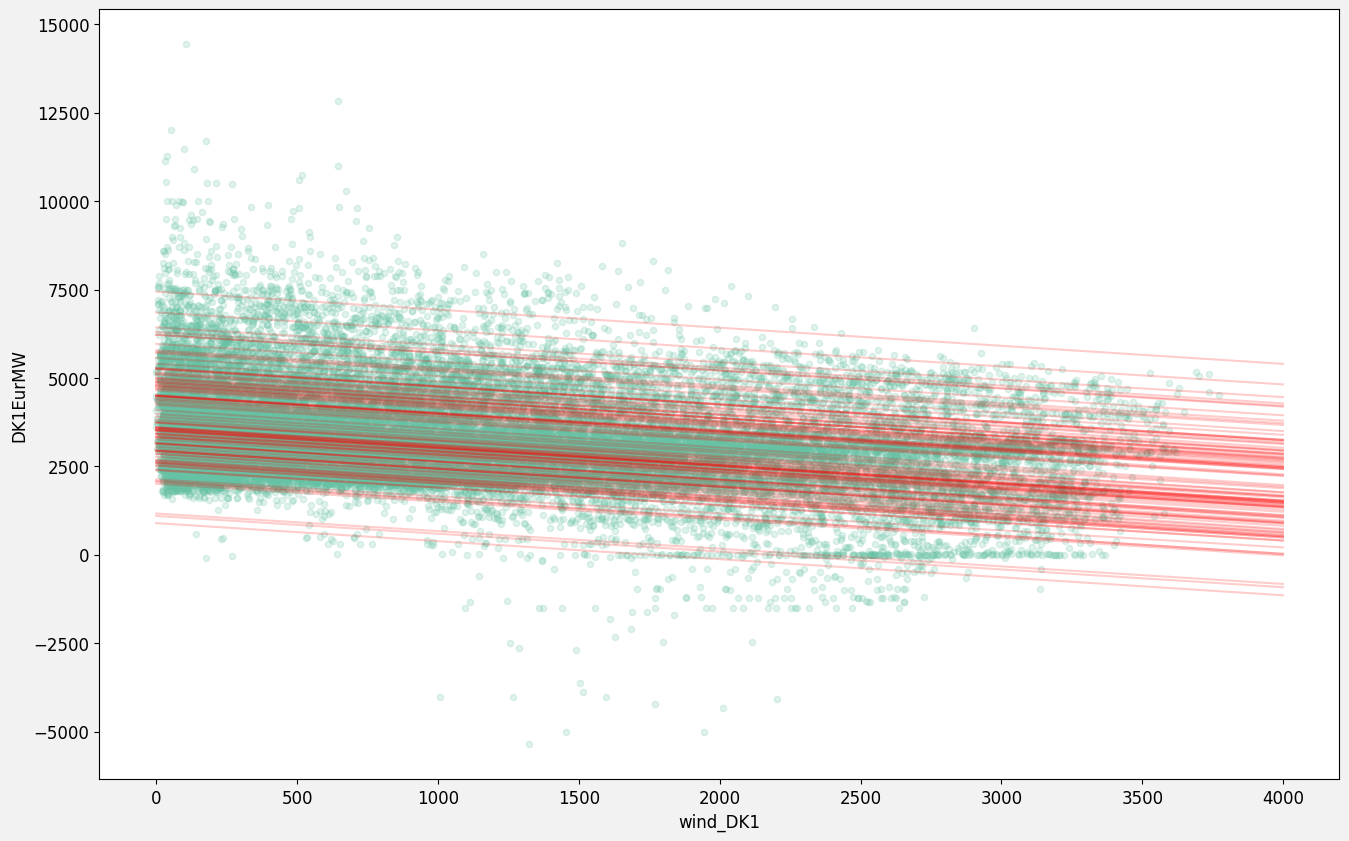

In [304]:
# Visualize the predictive distribution of the model:
x_line = np.arange(0, 4000, 1)

fig, ax = plt.subplots()
elDF.plot.scatter(x = 'wind_DK1', y = 'DK1EurMW', ax = ax, alpha = .2)

for i, row in simsDF.iloc[:100, :].iterrows():
    y_line = row[0] + row[1] * x_line + np.random.normal(0, sigma_hat)
    ax.plot(x_line, y_line, color = 'red', alpha = .2)

plt.show()

In [305]:
# For no-investment scenario, using the mean of the wind power variable for simplicity.
# For investment scenario, add an expected .5 * 400 = 200 MWH of wind production.
meanWind = np.mean(elDF['wind_DK1']) # mean amount of wind.

newWind = .5 * 400
expectedWind = meanWind + newWind # add expected wind production to the mean.

In [306]:
simsDF['simPrices'] = simsDF.iloc[:, 0] + simsDF.iloc[:, 1] * meanWind + np.random.normal(0, sigma_hat, nsim)
simsDF['simPricesHighWind'] = simsDF.iloc[:, 0] + simsDF.iloc[:, 1] * expectedWind + np.random.normal(0, sigma_hat, nsim)

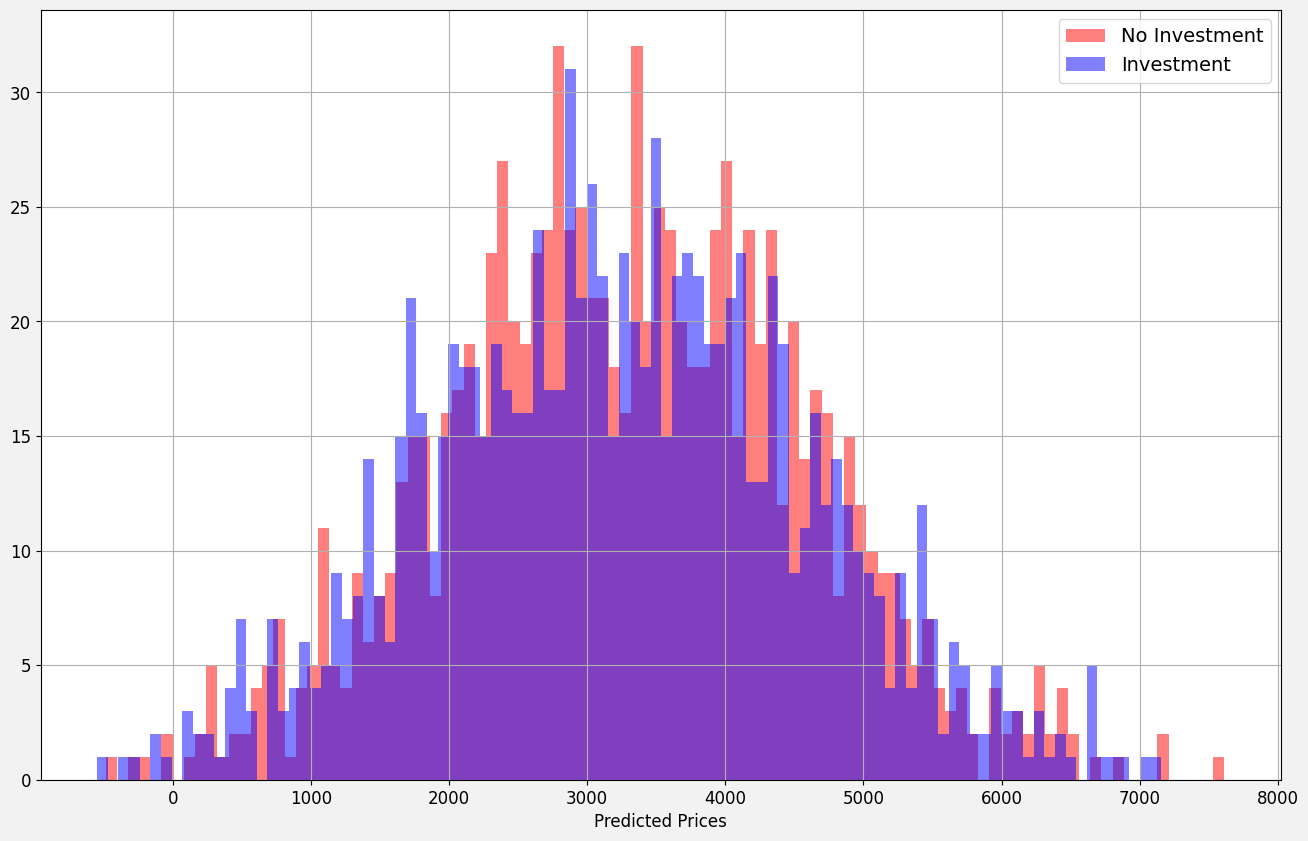

In [307]:
# Look at histogram of the expected prices for the two scenarios:
fig, ax = plt.subplots()
simsDF['simPrices'].hist(bins = 100, ax = ax, label = 'No Investment', alpha = .5, color = 'red')
simsDF['simPricesHighWind'].hist(bins = 100, ax = ax, label = 'Investment', alpha = .5, color = 'blue')
ax.set_xlabel('Predicted Prices')
ax.legend()
plt.show()

In [308]:
# Profit function:
investmentCost = 300000000
existingWindCap = 500 # How much existing wind capacity the company owns.
newWind = 400 # Size in capacity of new investment. 
cfWind = .5 # Capacity factor of wind power. 

thermalCap = 1000 # How much thermal capacity the company owns. 
mcThermal = 2000 # Marginal cost of the thermal capacity owned by the company. 
n = 1000 # 1000 period. 

In [309]:
def profitFunction(row):
    operProfit = row['simPrices'] * existingWindCap * cfWind
    if row['simPrices'] > mcThermal:
        operProfit += (row['simPrices'] - mcThermal) * thermalCap
    row['profit'] = operProfit * n

    operProfitHighWind = row['simPricesHighWind'] * (existingWindCap + newWind) * cfWind
    if row['simPricesHighWind'] > mcThermal:
        operProfitHighWind += (row['simPricesHighWind'] - mcThermal) * thermalCap
    row['profitHighWind'] = operProfitHighWind * n - investmentCost

    return row

In [310]:
newSimsDF = simsDF.apply(profitFunction, axis = 1)
newSimsDF

,0,1,simPrices,simPricesHighWind,profit,profitHighWind
0,3971.973307,-0.514984,4146.884152,4085.294838,3.183605e+09,3.623678e+09
1,3958.222993,-0.511422,3462.100351,1745.268829,2.327625e+09,4.853710e+08
2,3988.942163,-0.530993,1764.372369,3959.106184,4.410931e+08,3.440704e+09
3,3968.765527,-0.511251,6347.330101,2648.191765,5.934163e+09,1.539878e+09
4,3960.046204,-0.509576,4110.871034,3437.812056,3.138589e+09,2.684827e+09
...,...,...,...,...,...,...
995,3965.438310,-0.521316,4424.575369,4126.642182,3.530719e+09,3.683631e+09
996,3944.930055,-0.508785,3929.557998,2627.267768,2.911947e+09,1.509538e+09
997,3960.791237,-0.509383,1346.433853,2471.397065,3.366085e+08,1.283526e+09
998,3966.102149,-0.520651,3858.117162,1444.792353,2.822646e+09,3.501566e+08


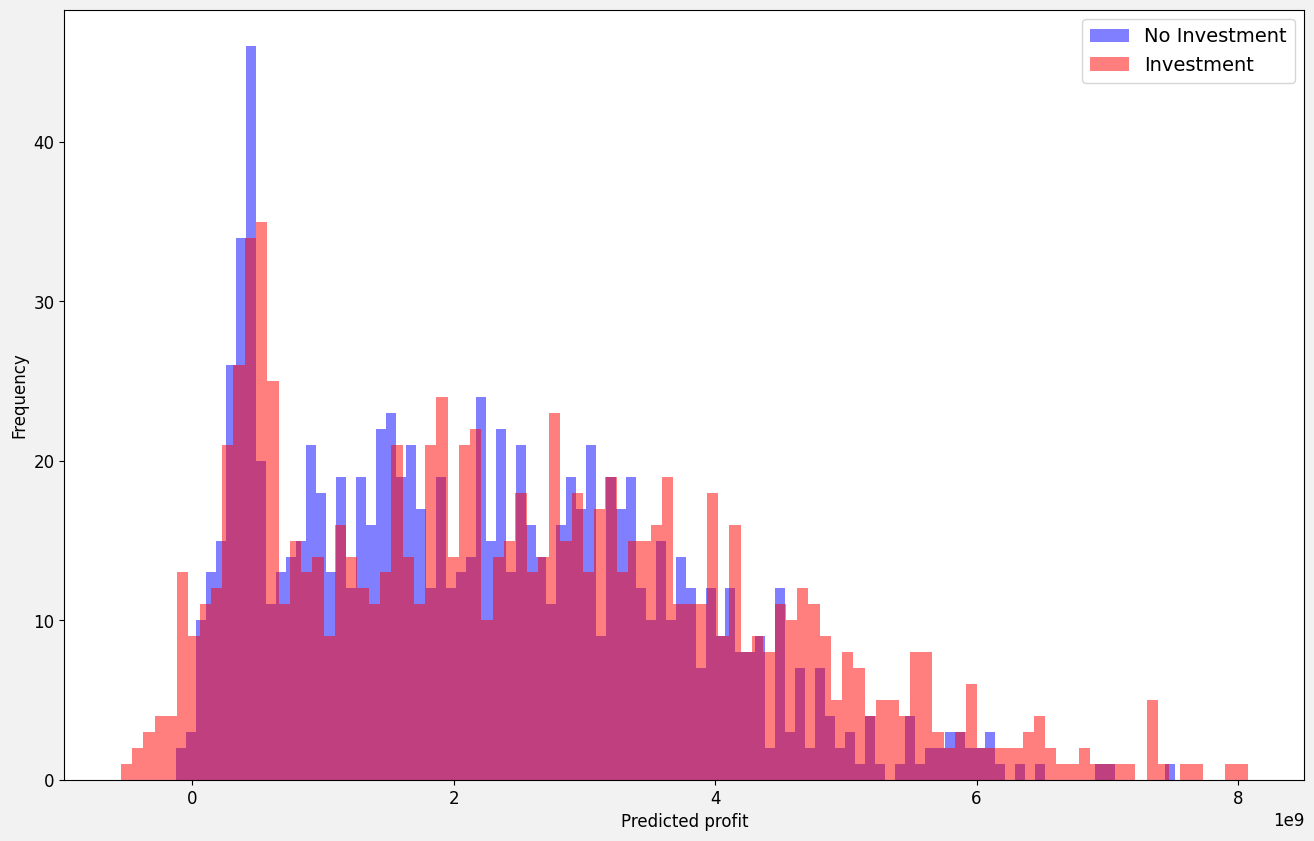

In [311]:
# Looking at the distributions of potential profit scenarios:
fig, ax = plt.subplots()
newSimsDF['profit'].plot.hist(bins = 100, ax = ax, label = 'No Investment', alpha = .5, color = 'blue')
newSimsDF['profitHighWind'].plot.hist(bins = 100, ax = ax, label = 'Investment', alpha = .5, color = 'red')
ax.set_xlabel('Predicted profit')
ax.legend()
plt.show()

In [312]:
# Decision Rule:
# Compare the expectated (mean) profits and see which is higher:
expectedProfit = newSimsDF['profit'].mean()
expectedProfitHighWind = newSimsDF['profitHighWind'].mean()

In [313]:
print('Expected profit, no investment:\t', expectedProfit)
print('Expected profit, investment:\t', expectedProfitHighWind)

Expected profit, no investment:	 2218664977.8754334
Expected profit, investment:	 2535237351.6760535


In [314]:
if expectedProfitHighWind > expectedProfit:
    print('Invest')
else:
    print('Do not invest')

Invest


In [315]:
# Look at which decision leads to the smallest probability of loss:
nLoss = np.sum(newSimsDF['profit'] < 0) / nsim
nLossHighWind = np.sum(newSimsDF['profitHighWind'] < 0) / nsim
print('Probability of loss, no investment:\t', nLoss * 100)
print('Probability of loss, investment:\t', nLossHighWind * 100)

Probability of loss, no investment:	 0.5
Probability of loss, investment:	 2.8000000000000003
